## Colab Setup

In [1]:
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL  = "https://github.com/tackes/Modern-Time-Series-Forecasting-Cohort.git"
    REPO_PATH = "/content/packt-modern-time-series"

    if not os.path.exists(REPO_PATH):
        os.system(f"git clone -q {REPO_URL} {REPO_PATH}")

    os.chdir(f"{REPO_PATH}/instructor_notebooks")

    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)

print(f"✓ Setup complete — {os.getcwd()}")

✓ Setup complete — c:\Users\tacke\Documents\packt-modern-time-series\instructor_notebooks


# Module 8 — Final Evaluation & Ship-It Decision
**Type:** [Watch Only]  
**Time:** 15 minutes  
**Job:** Assemble the master leaderboard. Make a defensible model selection recommendation. Save the final artifact.



---
## 8.1 — Setup
**[Watch Only]**

---

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams['figure.figsize'] = (14, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from config import ARTIFACT_DIR, WORKSHOP_SUBSET_N, HORIZON, N_WINDOWS, MICRO_SUBSET_N
from src.checkpointing import load_checkpoint
from src.evaluation import score_forecasts, build_leaderboard
from src.plotting import plot_metric_leaderboard

print("Setup complete.")

Setup complete.


---
## 8.2 — Load All Scored Artifacts
**[Watch Only]**

---

In [3]:
baseline_full = load_checkpoint("04_baseline_forecasts")
ml_full       = load_checkpoint("05_ml_forecasts")
dl_full       = load_checkpoint("06_dl_forecasts")

subset_label    = f"workshop_{WORKSHOP_SUBSET_N}"
baseline_scores = score_forecasts(baseline_full, subset_name=subset_label)
ml_scores       = score_forecasts(ml_full,       subset_name=subset_label)
dl_scores       = score_forecasts(dl_full,       subset_name=subset_label)

master_lb = build_leaderboard([baseline_scores, ml_scores, dl_scores])

print(f"Master leaderboard: {len(master_lb)} models")
master_lb


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 04_baseline_forecasts
    File     : 04_baseline_forecasts.parquet
    Rows     : 336,000


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 05_ml_forecasts
    File     : 05_ml_forecasts.parquet
    Rows     : 84,000


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 06_dl_forecasts
    File     : 06_dl_forecasts.parquet
    Rows     : 84,000

Master leaderboard: 6 models


,model,stage,subset_name,Bias,Coverage_80,IntervalScore_80,wMAPE
0,NHITS,dl,workshop_1000,-0.101875,0.659964,26.606782,0.438445
1,LightGBM,ml,workshop_1000,0.018044,0.672083,25.613683,0.465202
2,AutoETS,baseline,workshop_1000,0.000437,0.899393,25.584162,0.474567
3,Chronos-t5-mini,baseline,workshop_1000,-0.169574,0.728393,27.208518,0.492306
4,SeasonalNaive,baseline,workshop_1000,-0.025829,0.944333,32.539743,0.558018
5,Naive,baseline,workshop_1000,0.169000,0.982369,54.956852,0.665166


**Expected output:**
```
Master leaderboard: 6 models
          model stage         subset_name   Bias  Coverage_80  IntervalScore_80    wMAPE
       LightGBM    ml  workshop_1000        X.XXX  0.XX         XX.XXXX          0.XXXX
          NHITS    dl  workshop_1000        X.XXX  0.XX         XX.XXXX          0.XXXX
        AutoETS  base  workshop_1000        X.XXX  0.XX         XX.XXXX          0.XXXX
Chronos-t5-mini  base  workshop_1000        X.XXX  0.XX         XX.XXXX          0.XXXX
  SeasonalNaive  base  workshop_1000        X.XXX  0.XX         XX.XXXX          0.XXXX
          Naive  base  workshop_1000        X.XXX  0.XX         XX.XXXX          0.XXXX
```

---
## 8.3 — Final wMAPE Leaderboard Chart
**[Watch Only]**

---

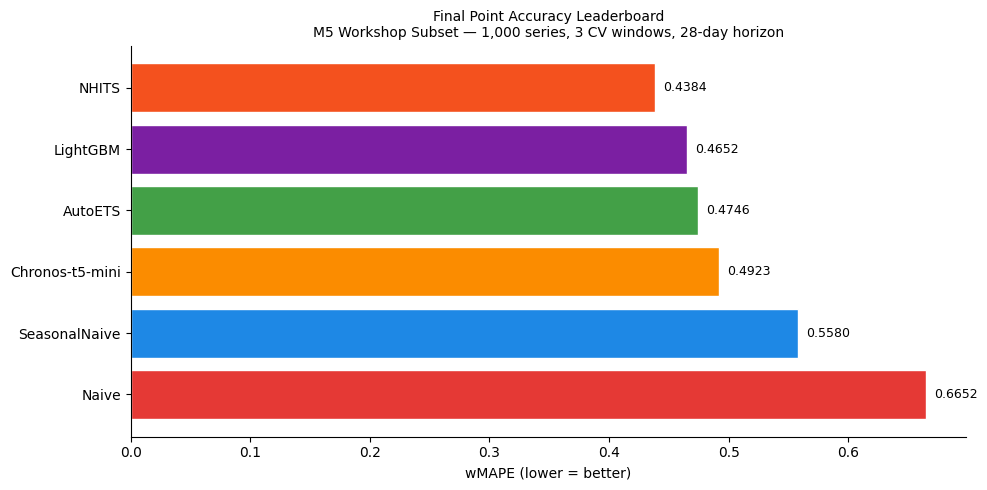

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Final Point Accuracy Leaderboard\nM5 Workshop Subset — 1,000 series, 3 CV windows, 28-day horizon'}, xlabel='wMAPE (lower = better)'>)

In [4]:
plot_metric_leaderboard(
    df=master_lb,
    metric="wMAPE",
    title=(
        f"Final Point Accuracy Leaderboard\n"
        f"M5 Workshop Subset — {WORKSHOP_SUBSET_N:,} series, "
        f"{N_WINDOWS} CV windows, {HORIZON}-day horizon"
    ),
    figsize=(10, 5),
)

**Expected output:** Six-model horizontal bar chart sorted by wMAPE ascending with stage labels embedded.

---
## 8.4 — Two-Axis Comparison: Accuracy and Uncertainty
**[Watch Only]**

---

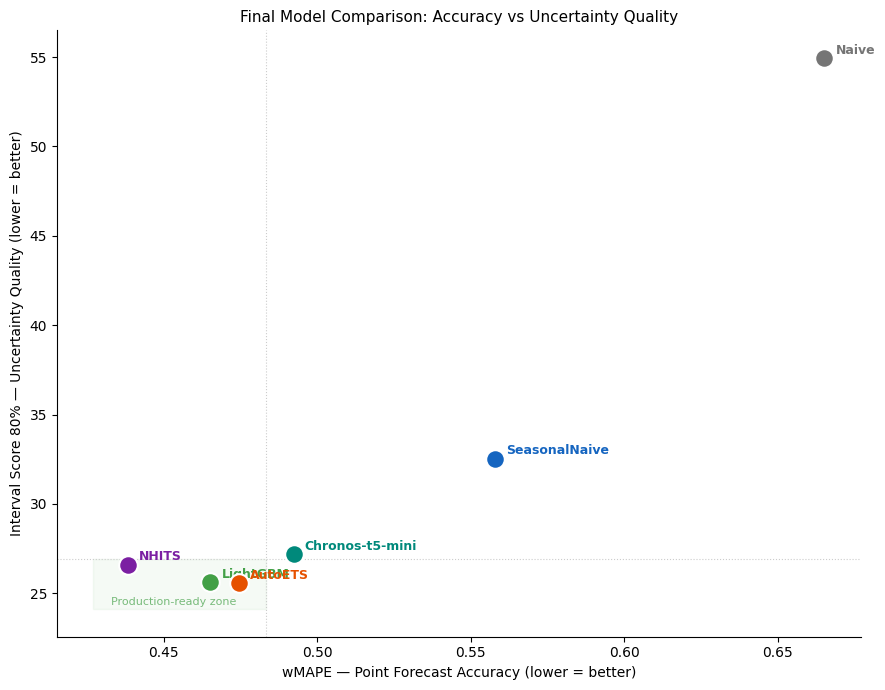

In [5]:
model_styles = {
    "LightGBM":       "#43A047",
    "LightGBM-Rich":  "#2E7D32",
    "LightGBM-Cat":   "#66BB6A",
    "NHITS":          "#7B1FA2",
    "AutoETS":        "#E65100",
    "Chronos-t5-mini":"#00897B",
    "SeasonalNaive":  "#1565C0",
    "Naive":          "#757575",
}

if "IntervalScore_80" in master_lb.columns and "wMAPE" in master_lb.columns:
    plot_data = master_lb.dropna(subset=["wMAPE", "IntervalScore_80"])

    fig, ax = plt.subplots(figsize=(9, 7))

    for _, row in plot_data.iterrows():
        color = model_styles.get(row["model"], "#555")
        ax.scatter(row["wMAPE"], row["IntervalScore_80"],
                   s=180, color=color, zorder=4, edgecolors="white", linewidth=1.5)
        ax.annotate(
            row["model"],
            xy=(row["wMAPE"], row["IntervalScore_80"]),
            xytext=(8, 3), textcoords="offset points",
            fontsize=9, color=color, fontweight="bold"
        )

    # Shade the "ideal" bottom-left quadrant
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    wmape_mid  = plot_data["wMAPE"].median()
    iscore_mid = plot_data["IntervalScore_80"].median()
    ax.axvline(wmape_mid,  color="#ccc", linestyle=":", linewidth=0.8)
    ax.axhline(iscore_mid, color="#ccc", linestyle=":", linewidth=0.8)
    ax.fill_between(
        [xlim[0], wmape_mid], ylim[0], iscore_mid,
        alpha=0.05, color="#43A047"
    )
    ax.text(xlim[0] + (wmape_mid - xlim[0]) * 0.1, ylim[0] + (iscore_mid - ylim[0]) * 0.08,
            "Production-ready zone", fontsize=8, color="#43A047", alpha=0.7)

    ax.set_xlabel("wMAPE — Point Forecast Accuracy (lower = better)", fontsize=10)
    ax.set_ylabel("Interval Score 80% — Uncertainty Quality (lower = better)", fontsize=10)
    ax.set_title("Final Model Comparison: Accuracy vs Uncertainty Quality", fontsize=11)
    plt.tight_layout()
    plt.show()

**Expected output:** Scatter plot with shaded "production-ready zone" in the bottom-left. Models in or near the zone are candidates for deployment.

---
## 8.5 — The Ship-It Framework
**[Watch Only]**



You have a leaderboard. You have interval scores. Now make a decision.

**The question is not: which model has the best wMAPE?**  
The question is: **which model should go into production, given the operational constraints of your team?**

These are different questions. Use this framework:

---

### Step 1 — Eliminate models that fail the operational floor

Any model that cannot clear these thresholds is not a candidate regardless of accuracy:
- Can it retrain on a daily or weekly cadence within your compute budget?
- Can your team debug it when it fails in production?
- Does it have a clear owner who will maintain it?

Naive and SeasonalNaive pass all three. AutoETS passes. LightGBM and NHITS require infrastructure. Chronos requires GPU inference at scale.

---

### Step 2 — Quantify the accuracy improvement in business terms

A 3-point wMAPE improvement sounds meaningful. Connect it to a number:

- If your portfolio carries \$50M in inventory and you hold 2 weeks of safety stock,
  a 3-point wMAPE reduction translates to roughly \$1.5M in freed working capital.
- If your ML pipeline costs \$200K/year to run, maintain, and monitor — it pays for itself.
- If it costs \$2M — AutoETS is the better business decision even if LightGBM wins on accuracy.

**The leaderboard does not make this calculation. You do.**

---

### Step 3 — Check interval quality for your risk profile

If your procurement team uses forecast intervals to set safety stock:
- A model with better Interval Score reduces safety stock requirements directly
- A model that wins wMAPE but has erratic intervals cannot support that use case

Look at the scatter plot. If the wMAPE winner and the Interval Score winner are the same model, the decision is easy. If they differ, ask: which risk matters more — stockout risk (wMAPE) or overstocking risk (interval quality)?

---

### Step 4 — Make the call

A real recommendation sounds like this:

> *"Based on this evaluation, we recommend LightGBM for production. It delivers the best wMAPE and interval score on this portfolio, and the lag feature pipeline is manageable at our current scale. NHITS is not materially better to justify the GPU infrastructure. AutoETS remains the fallback if the feature pipeline degrades."*

That is a complete recommendation. It names a winner, justifies the choice, identifies the fallback, and draws a clear line at the infrastructure cost threshold.

---
## 8.6 — Save the Final Master Leaderboard
**[Watch Only]**

---

In [6]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
leaderboard_path = ARTIFACT_DIR / "08_final_master_leaderboard.csv"
master_lb.to_csv(leaderboard_path, index=False)

print(f"  ✓ Final leaderboard saved: {leaderboard_path.name}")
print(f"    Models : {len(master_lb)}")
print(f"    Columns: {list(master_lb.columns)}")
print()
print("All workshop artifacts are complete:")

from src.checkpointing import list_checkpoints
list_checkpoints()

  ✓ Final leaderboard saved: 08_final_master_leaderboard.csv
    Models : 6
    Columns: ['model', 'stage', 'subset_name', 'Bias', 'Coverage_80', 'IntervalScore_80', 'wMAPE']

All workshop artifacts are complete:

  ARTIFACT REGISTRY STATUS
  ----------------------------------------
  ✓ EXISTS  00_env_status                        00_env_status.json
  ✓ EXISTS  02_global_config                     02_global_config.pkl
  ✓ EXISTS  03_validated_panel                   03_validated_panel.parquet
  ✓ EXISTS  04_baseline_cv_scores                04_baseline_cv_scores.parquet
  ✓ EXISTS  04_baseline_forecasts                04_baseline_forecasts.parquet
  ✓ EXISTS  05_ml_cat_forecasts                  05_ml_cat_forecasts.parquet
  ✓ EXISTS  05_ml_forecasts                      05_ml_forecasts.parquet
  ✓ EXISTS  05_ml_rich_forecasts                 05_ml_rich_forecasts.parquet
  ✓ EXISTS  06_dl_forecasts                      06_dl_forecasts.parquet
  ✓ EXISTS  07_uncertainty_leaderboard     

**Expected output:**
```
  ✓ Final leaderboard saved: 08_final_master_leaderboard.csv
    Models : 6
    Columns: ['model', 'stage', 'subset_name', 'Bias', 'Coverage_80', 'IntervalScore_80', 'wMAPE']

All workshop artifacts are complete:

  ARTIFACT REGISTRY STATUS
  ----------------------------------------
  ✓ EXISTS  00_env_status              ...
  ✓ EXISTS  02_global_config           ...
  ...
  ✓ EXISTS  08_final_master_leaderboard ...
```